In [ ]:
import mip
from pathlib import Path

PROJECT_ROOT = Path(mip.__file__).parent.parent


In [1]:
import osmnx as ox
import networkx as nx
import json

# Start small — Kramatorsk is a key logistics city in the conflict zone
# G = ox.graph_from_place("Kramatorsk, Donetsk Oblast, Ukraine", network_type="drive")
G = ox.graph_from_place("Kramatorsk Raion, Donetsk Oblast, Ukraine", network_type="drive")

# Assign travel times based on road type
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)  # adds 'travel_time' in seconds to each edge

# Take largest connected component and convert to undirected for routing
G = ox.convert.to_undirected(G)
G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


Nodes: 11508, Edges: 16187


In [2]:
# Node list: (id, lat, lon)
nodes = {n: {"lat": data["y"], "lon": data["x"]} for n, data in G.nodes(data=True)}

# Edge list: (u, v, travel_time_seconds)
edges = []
for u, v, data in G.edges(data=True):
    t = data.get("travel_time", None)
    if t is not None:
        edges.append({"u": u, "v": v, "travel_time": t})

print(f"Nodes: {len(nodes)}, Edges: {len(edges)}")

# Quick sanity check — are travel times sensible?
import statistics
times = [e["travel_time"] for e in edges]
print(f"Travel time: min={min(times):.0f}s, mean={statistics.mean(times):.0f}s, max={max(times):.0f}s")


Nodes: 11508, Edges: 16187
Travel time: min=0s, mean=35s, max=1146s


In [ ]:
# # Manual fallback if add_edge_speeds gives bad results
# speed_map = {
#     "motorway": 110, "trunk": 90, "primary": 80,
#     "secondary": 60, "tertiary": 40,
#     "residential": 30, "unclassified": 25, "track": 15
# }
# for u, v, data in G.edges(data=True):
#     highway = data.get("highway", "unclassified")
#     if isinstance(highway, list):
#         highway = highway[0]
#     speed = speed_map.get(highway, 25)
#     length_km = data.get("length", 100) / 1000
#     data["travel_time"] = (length_km / speed) * 3600  # seconds


In [ ]:
# G = ox.add_edge_travel_times(G)

# # Verify
# times = [d["travel_time"] for u, v, d in G.edges(data=True)]
# import statistics
# print(f"min={min(times):.1f}s, mean={statistics.mean(times):.1f}s, max={max(times):.1f}s")
# # You should now have min > 0


min=0.3s, mean=23.7s, max=144.0s


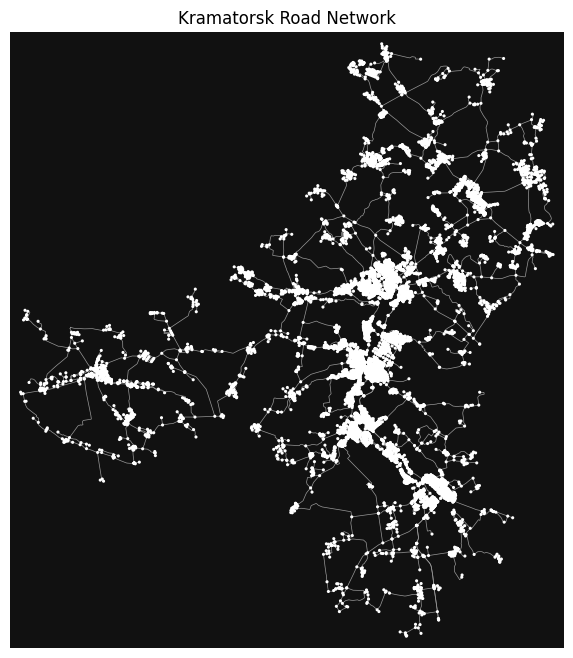

In [3]:
import matplotlib.pyplot as plt

fig, ax = ox.plot_graph(G, node_size=5, edge_linewidth=0.5, show=False, close=False)
plt.title("Kramatorsk Road Network")
plt.savefig(PROJECT_ROOT / "data/figures/network.png", dpi=150, bbox_inches="tight")
plt.show()


In [1]:
import osmnx as ox
import networkx as nx
import numpy as np
from sklearn.cluster import DBSCAN

# ── 1. Pull the full Kramatorsk Raion ──────────────────────────────────────
G_raw = ox.graph_from_place("Kramatorsk Raion, Donetsk Oblast, Ukraine", 
                             network_type="drive")
G_raw = ox.add_edge_speeds(G_raw)

# Fix zero/missing speeds
speed_map = {
    "motorway": 110, "trunk": 90, "primary": 80, "secondary": 60,
    "tertiary": 40, "residential": 30, "unclassified": 25, "track": 15
}
for u, v, data in G_raw.edges(data=True):
    if data.get("speed_kph", 0) == 0 or "speed_kph" not in data:
        highway = data.get("highway", "unclassified")
        if isinstance(highway, list):
            highway = highway[0]
        data["speed_kph"] = speed_map.get(highway, 25)

G_raw = ox.add_edge_travel_times(G_raw)
G_raw = ox.convert.to_undirected(G_raw)
G_raw = G_raw.subgraph(max(nx.connected_components(G_raw), key=len)).copy()

print(f"Raw: {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")


# ── 2. Coarsen via DBSCAN ─────────────────────────────────────────────────
def coarsen_graph(G, eps_deg):
    """
    Merge spatially nearby nodes into supernodes.
    eps_deg: cluster radius in degrees (~0.009 deg ≈ 1km at this latitude)
    """
    node_ids = list(G.nodes())
    coords = np.array([[G.nodes[n]['y'], G.nodes[n]['x']] for n in node_ids])
    
    labels = DBSCAN(eps=eps_deg, min_samples=1).fit(coords).labels_
    node_to_cluster = {node_ids[i]: labels[i] for i in range(len(node_ids))}
    
    CG = nx.Graph()
    
    # Add supernodes — centroid of all member nodes
    for cid in set(labels):
        members = [n for n, c in node_to_cluster.items() if c == cid]
        CG.add_node(cid,
            lat=np.mean([G.nodes[n]['y'] for n in members]),
            lon=np.mean([G.nodes[n]['x'] for n in members]),
            member_count=len(members)
        )
    
    # Add edges — minimum travel time between cluster pairs
    for u, v, data in G.edges(data=True):
        cu, cv = node_to_cluster[u], node_to_cluster[v]
        if cu == cv:
            continue  # internal edge, skip
        t = data.get("travel_time", float("inf"))
        if CG.has_edge(cu, cv):
            if t < CG[cu][cv]["travel_time"]:
                CG[cu][cv]["travel_time"] = t
        else:
            CG.add_edge(cu, cv, travel_time=t)
    
    # Keep only largest connected component
    CG = CG.subgraph(max(nx.connected_components(CG), key=len)).copy()
    return CG


# ── 3. Try three eps values to hit your scale targets ─────────────────────
for eps in [0.005, 0.010, 0.020]:
    CG = coarsen_graph(G_raw, eps_deg=eps)
    print(f"eps={eps:.3f} (~{eps*111:.0f}km): "
          f"{CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")


Raw: 11508 nodes, 16187 edges
eps=0.005 (~1km): 768 nodes, 933 edges
eps=0.010 (~1km): 351 nodes, 447 edges
eps=0.020 (~2km): 113 nodes, 155 edges



eps=0.005 ~1km
  Nodes: 768, Edges: 933
  Travel time (s): min=14.8, mean=157.6, median=113.9, max=1145.5
  Travel time (min): min=0.2, mean=2.6, median=1.9, max=19.1

eps=0.010 ~1km
  Nodes: 351, Edges: 447
  Travel time (s): min=37.0, mean=228.0, median=175.4, max=1145.5
  Travel time (min): min=0.6, mean=3.8, median=2.9, max=19.1

eps=0.020 ~2km
  Nodes: 113, Edges: 155
  Travel time (s): min=93.6, mean=321.7, median=273.2, max=1145.5
  Travel time (min): min=1.6, mean=5.4, median=4.6, max=19.1


/var/folders/dr/xp_zz5ls1tjf54gxzsbf2g55q3psbz/T/ipykernel_76228/319713754.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


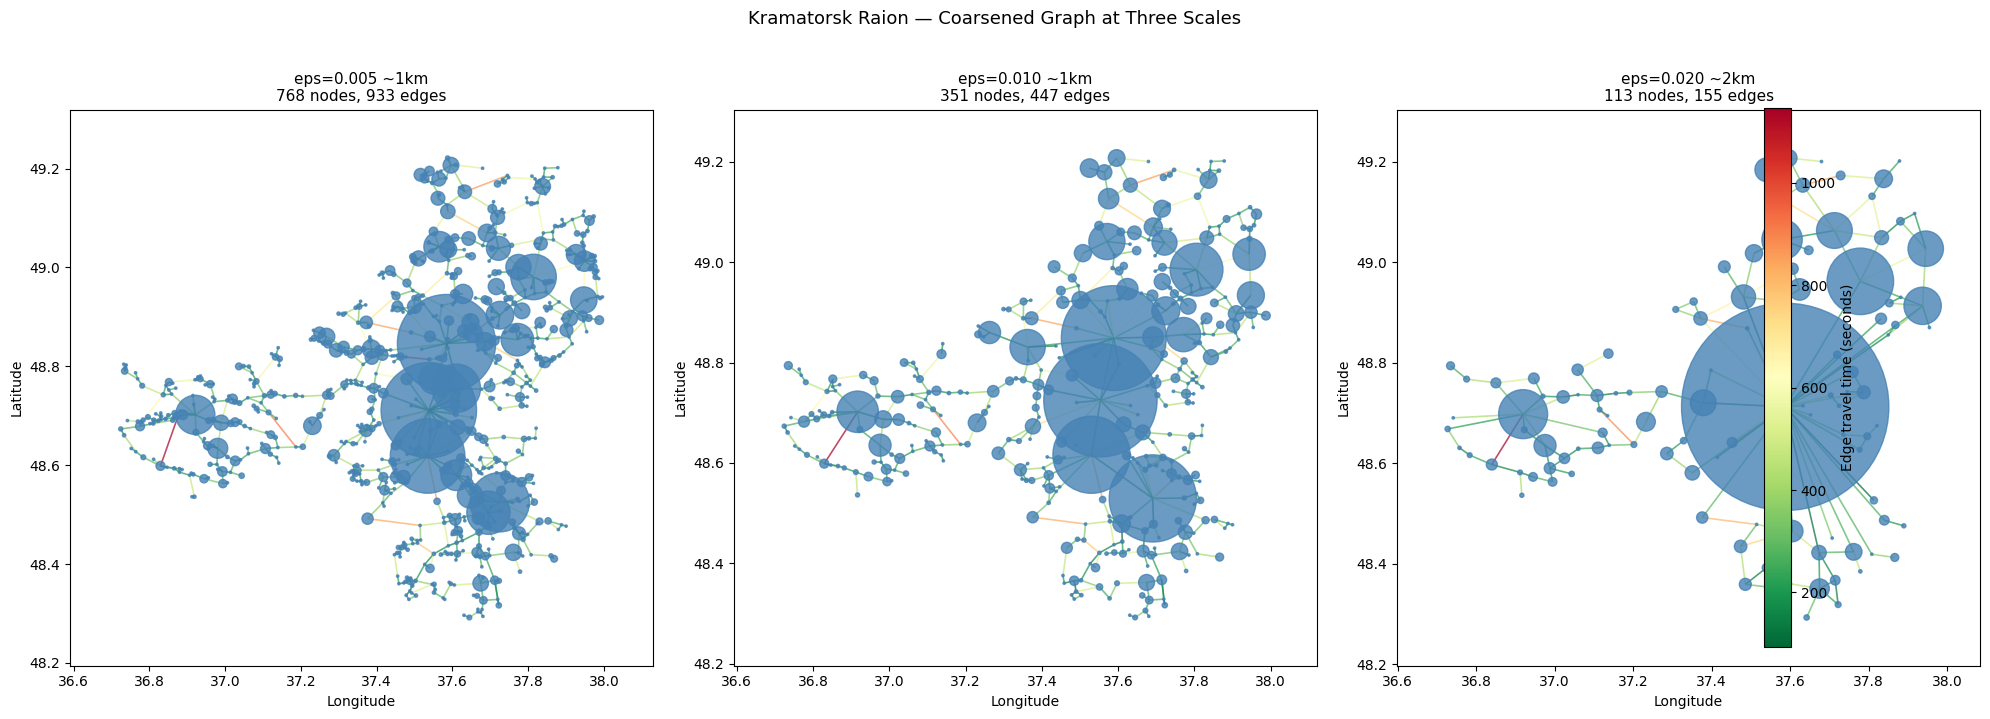

In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import statistics

eps_configs = [
    (0.005, "eps=0.005 ~1km"),
    (0.010, "eps=0.010 ~1km"),
    (0.020, "eps=0.020 ~2km"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (eps, label) in zip(axes, eps_configs):
    CG = coarsen_graph(G_raw, eps_deg=eps)
    
    # ── Travel time stats ──────────────────────────────────────────────
    times = [d["travel_time"] for u, v, d in CG.edges(data=True)]
    print(f"\n{label}")
    print(f"  Nodes: {CG.number_of_nodes()}, Edges: {CG.number_of_edges()}")
    print(f"  Travel time (s): min={min(times):.1f}, mean={statistics.mean(times):.1f}, "
          f"median={statistics.median(times):.1f}, max={max(times):.1f}")
    print(f"  Travel time (min): min={min(times)/60:.1f}, mean={statistics.mean(times)/60:.1f}, "
          f"median={statistics.median(times)/60:.1f}, max={max(times)/60:.1f}")
    
    # ── Layout from lat/lon ────────────────────────────────────────────
    pos = {n: (d["lon"], d["lat"]) for n, d in CG.nodes(data=True)}
    
    # ── Colour edges by travel time ────────────────────────────────────
    edge_times = [CG[u][v]["travel_time"] for u, v in CG.edges()]
    norm = mcolors.Normalize(vmin=min(edge_times), vmax=max(edge_times))
    cmap = cm.RdYlGn_r  # green=fast, red=slow
    edge_colors = [cmap(norm(t)) for t in edge_times]
    
    # ── Node size = number of original nodes merged into supernode ─────
    node_sizes = [CG.nodes[n].get("member_count", 1) * 3 for n in CG.nodes()]
    
    import networkx as nx
    nx.draw_networkx_nodes(CG, pos, ax=ax, node_size=node_sizes,
                           node_color="steelblue", alpha=0.8)
    nx.draw_networkx_edges(CG, pos, ax=ax, edge_color=edge_colors,
                           width=1.2, alpha=0.7)
    
    ax.set_title(f"{label}\n{CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges", 
                 fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# ── Shared colorbar ────────────────────────────────────────────────────
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("Edge travel time (seconds)", fontsize=10)

plt.suptitle("Kramatorsk Raion — Coarsened Graph at Three Scales", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/coarsened_graphs.png", dpi=150, bbox_inches="tight")
plt.show()


In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

# ── 1. Load and filter ────────────────────────────────────────────────────
df = pd.read_csv(PROJECT_ROOT / "data/ACLED Data_2026-03-25.csv")

# Filter to Ukraine only, 2022 onwards, and to your bounding box
df = df[
    (df["country"] == "Ukraine") &
    (df["year"] >= 2022) &
    (df["latitude"].between(48.2, 49.3)) &   # Kramatorsk Raion bbox
    (df["longitude"].between(36.6, 38.1))
]

print(f"Events in region: {len(df)}")
print(df["event_type"].value_counts())  # see what kinds of events you have

# ── 2. Cluster spatially ──────────────────────────────────────────────────
coords = df[["latitude", "longitude"]].values

# eps=0.05 ≈ 5km radius — each cluster becomes one demand node
clustering = DBSCAN(eps=0.05, min_samples=3).fit(coords)
df["cluster"] = clustering.labels_

# How many clusters did we get? (-1 = noise, not assigned to any cluster)
n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
n_noise = (clustering.labels_ == -1).sum()
print(f"\nClusters: {n_clusters}, Noise points (unassigned): {n_noise}")

# ── 3. Build demand node table ────────────────────────────────────────────
# For each cluster: centroid lat/lon + total fatalities as demand intensity
demand_raw = (
    df[df["cluster"] >= 0]
    .groupby("cluster")
    .agg(
        lat=("latitude", "mean"),
        lon=("longitude", "mean"),
        n_events=("event_type", "count"),
        total_fatalities=("fatalities", "sum")
    )
    .reset_index(drop=True)
)

print(f"\nDemand nodes before snapping: {len(demand_raw)}")
print(demand_raw.sort_values("n_events", ascending=False).head(10))


Events in region: 29174
event_type
Explosions/Remote violence    17029
Battles                       11457
Strategic developments          605
Violence against civilians       81
Protests                          2
Name: count, dtype: int64

Clusters: 93, Noise points (unassigned): 28

Demand nodes before snapping: 93
          lat        lon  n_events  total_fatalities
2   48.515091  37.929605     14114             10843
4   48.254081  37.479658      3437             12904
15  49.116422  37.962994      1882              1714
68  48.495788  37.960030      1771              1200
3   48.268556  37.779578       908               438
35  49.017782  37.952002       845               561
31  49.226500  37.986300       504              1215
43  48.872600  38.096000       439               192
38  49.217569  37.850208       366               141
24  49.000936  37.381734       335               154


In [4]:
df = df[df["event_type"].isin(["Explosions/Remote violence", "Battles", "Violence against civilians"])]
print(f"Filtered events: {len(df)}")


Filtered events: 28567


In [6]:
df = df[
    (df["country"] == "Ukraine") &
    (df["year"] >= 2022) &
    (df["latitude"].between(48.2, 49.3)) &
    (df["longitude"].between(36.6, 38.1)) &
    (df["event_type"].isin(["Explosions/Remote violence", "Battles", "Violence against civilians"]))
]

print(f"Filtered violent events in region: {len(df)}")

# ── 2. Try multiple eps values to find right cluster count ────────────────
coords = df[["latitude", "longitude"]].values

print("\nClustering results:")
for eps in [0.05, 0.06, 0.07, 0.08, 0.09, 0.10]:
    labels = DBSCAN(eps=eps, min_samples=5).fit(coords).labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps:.2f}: {n_clusters} clusters")


Filtered violent events in region: 28567

Clustering results:
eps=0.05: 81 clusters
eps=0.06: 45 clusters
eps=0.07: 23 clusters
eps=0.08: 13 clusters
eps=0.09: 6 clusters
eps=0.10: 3 clusters



Demand nodes with eps=0.08: 13
          lat        lon  n_events  total_fatalities
0   48.614768  37.825851     28047             32395
4   48.902500  37.018900        79                45
11  49.208800  38.083200       137                45
3   49.174500  37.427200        17                22
2   49.120628  37.003155        88                18
1   49.172785  36.903677        97                13
5   48.832300  37.387675        16                 8
10  49.015729  36.677671         7                 5
6   49.277392  37.106708        12                 3
7   48.646861  36.983511        18                 3
9   48.243338  36.761375         8                 3
12  48.666331  37.362062        13                 3
8   48.925971  36.917071         7                 1


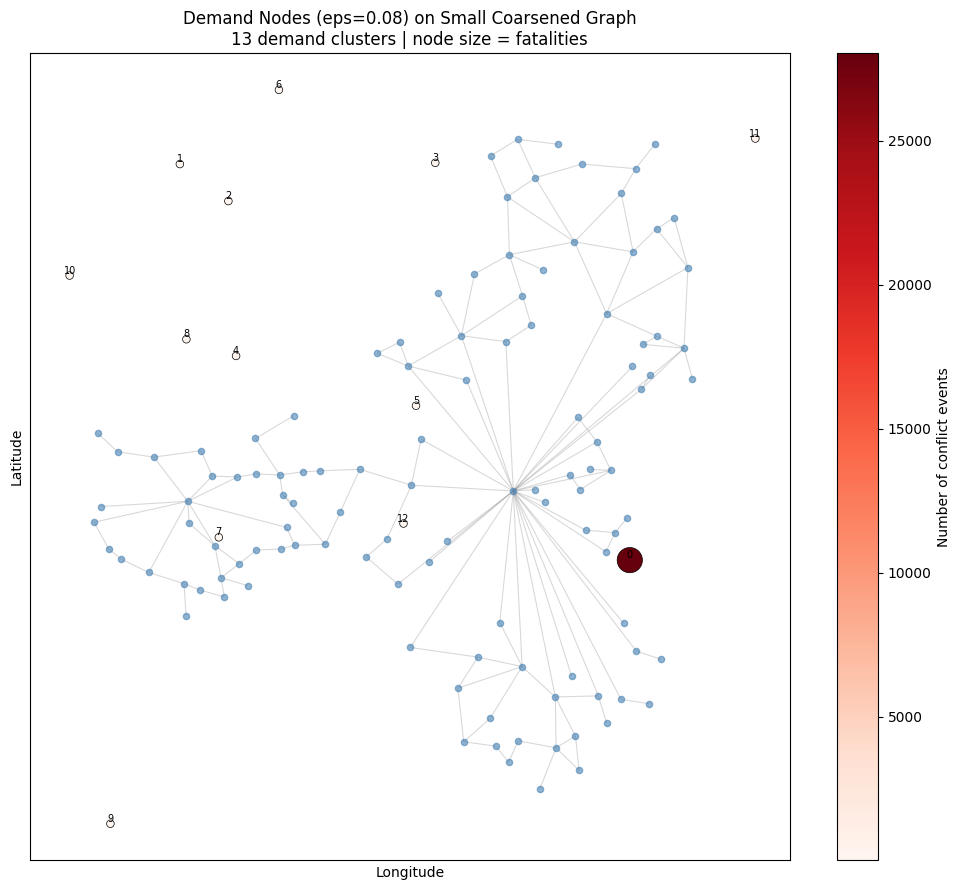

In [7]:
CHOSEN_EPS = 0.08

labels = DBSCAN(eps=CHOSEN_EPS, min_samples=5).fit(coords).labels_
df["cluster"] = labels

demand_raw = (
    df[df["cluster"] >= 0]
    .groupby("cluster")
    .agg(
        lat=("latitude", "mean"),
        lon=("longitude", "mean"),
        n_events=("event_type", "count"),
        total_fatalities=("fatalities", "sum")
    )
    .reset_index(drop=True)
)

print(f"\nDemand nodes with eps={CHOSEN_EPS}: {len(demand_raw)}")
print(demand_raw.sort_values("total_fatalities", ascending=False).to_string())

# ── 4. Visualize demand nodes on top of the Small coarsened graph ─────────
import matplotlib.pyplot as plt
import networkx as nx

# Build the Small instance (eps=0.020)
CG_small = coarsen_graph(G_raw, eps_deg=0.020)
pos = {n: (d["lon"], d["lat"]) for n, d in CG_small.nodes(data=True)}

fig, ax = plt.subplots(figsize=(10, 9))

# Draw road graph
nx.draw_networkx_edges(CG_small, pos, ax=ax, alpha=0.3, edge_color="gray", width=0.8)
nx.draw_networkx_nodes(CG_small, pos, ax=ax, node_size=20,
                       node_color="steelblue", alpha=0.6)

# Overlay demand clusters — size proportional to fatalities
scatter = ax.scatter(
    demand_raw["lon"],
    demand_raw["lat"],
    s=demand_raw["total_fatalities"] / demand_raw["total_fatalities"].max() * 300 + 30,
    c=demand_raw["n_events"],
    cmap="Reds",
    zorder=5,
    edgecolors="black",
    linewidths=0.5,
    label="Demand node (ACLED cluster)"
)

# Label each demand node with its index
for idx, row in demand_raw.iterrows():
    ax.annotate(str(idx), (row["lon"], row["lat"]),
                fontsize=7, ha="center", va="bottom", zorder=6)

plt.colorbar(scatter, ax=ax, label="Number of conflict events")
ax.set_title(f"Demand Nodes (eps={CHOSEN_EPS}) on Small Coarsened Graph\n"
             f"{len(demand_raw)} demand clusters | node size = fatalities")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/demand_nodes.png", dpi=150, bbox_inches="tight")
plt.show()


Pulling road graph...


/Users/sohans/Projects/CSCI617_MIO_project/ukraine-medical-logistics/.venv/lib/python3.11/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 422 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Raw graph: 1448571 nodes, 1883308 edges
eps=0.01: 35869 nodes, 43528 edges
eps=0.015: 22682 nodes, 27945 edges
eps=0.02: 14639 nodes, 18273 edges

Coarsened: 22682 nodes, 27945 edges
Travel time (min): min=0.7, mean=5.1, max=176.1

Loading ACLED...
Conflict events in corridor: 17053
  ACLED eps=0.03: 94 clusters
  ACLED eps=0.05: 23 clusters
  ACLED eps=0.07: 5 clusters
  ACLED eps=0.1: 1 clusters

Demand clusters: 23
          lat        lon  n_events  total_fatalities
0   48.528840  37.935206     13924             10834
11  48.495814  37.960025      1768              1200
5   48.319566  37.529923       187              1017
2   48.730928  37.582000       254               335
4   48.318795  37.762270       129               245
18  48.807448  37.554426        23               210
8   48.308950  37.445933        72                81
9   48.804300  38.147400       309                39
3   48.616500  37.529200       100                32
12  48.342467  37.677892        36              

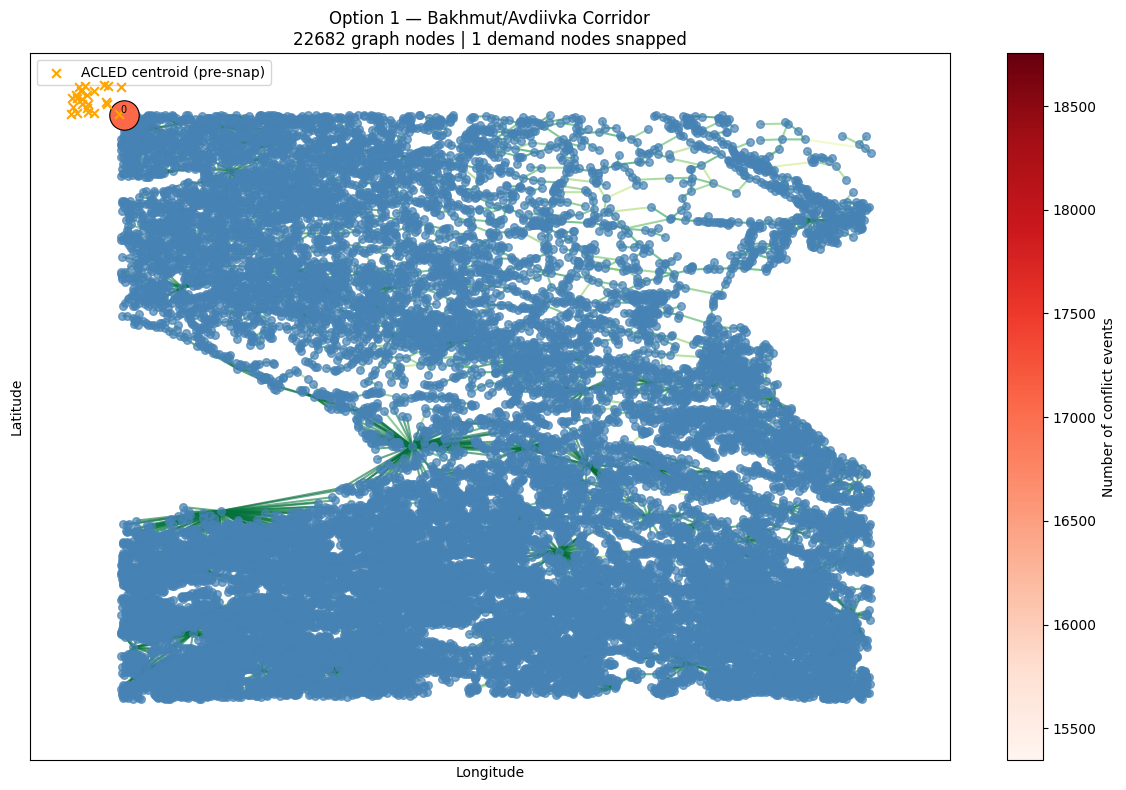

In [11]:
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statistics
from sklearn.cluster import DBSCAN

# ── 1. Pull road graph for the conflict corridor ──────────────────────────
print("Pulling road graph...")
G_raw = ox.graph_from_bbox(
    bbox=(48.85, 48.30, 38.15, 37.40),  # north, south, east, west
    network_type="drive"
)
G_raw = ox.add_edge_speeds(G_raw)

for u, v, data in G_raw.edges(data=True):
    if data.get("speed_kph", 0) == 0 or "speed_kph" not in data:
        highway = data.get("highway", "unclassified")
        if isinstance(highway, list): highway = highway[0]
        defaults = {"motorway":110,"trunk":90,"primary":80,"secondary":60,
                    "tertiary":40,"residential":30,"unclassified":25,"track":15}
        data["speed_kph"] = defaults.get(highway, 25)

G_raw = ox.add_edge_travel_times(G_raw)
G_raw = ox.convert.to_undirected(G_raw)
G_raw = G_raw.subgraph(max(nx.connected_components(G_raw), key=len)).copy()
print(f"Raw graph: {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")

# ── 2. Coarsen ────────────────────────────────────────────────────────────
def coarsen_graph(G, eps_deg):
    from sklearn.cluster import DBSCAN
    node_ids = list(G.nodes())
    coords = np.array([[G.nodes[n]['y'], G.nodes[n]['x']] for n in node_ids])
    labels = DBSCAN(eps=eps_deg, min_samples=1).fit(coords).labels_
    node_to_cluster = {node_ids[i]: labels[i] for i in range(len(node_ids))}
    CG = nx.Graph()
    for cid in set(labels):
        members = [n for n, c in node_to_cluster.items() if c == cid]
        CG.add_node(cid,
            lat=np.mean([G.nodes[n]['y'] for n in members]),
            lon=np.mean([G.nodes[n]['x'] for n in members]),
            member_count=len(members))
    for u, v, data in G.edges(data=True):
        cu, cv = node_to_cluster[u], node_to_cluster[v]
        if cu == cv: continue
        t = data.get("travel_time", float("inf"))
        if CG.has_edge(cu, cv):
            if t < CG[cu][cv]["travel_time"]: CG[cu][cv]["travel_time"] = t
        else:
            CG.add_edge(cu, cv, travel_time=t)
    CG = CG.subgraph(max(nx.connected_components(CG), key=len)).copy()
    return CG

# Try a few eps values on this smaller area
for eps in [0.010, 0.015, 0.020]:
    CG = coarsen_graph(G_raw, eps)
    print(f"eps={eps}: {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")

# Pick whichever gives ~80-150 nodes — adjust this after seeing output
CHOSEN_EPS = 0.015
CG = coarsen_graph(G_raw, CHOSEN_EPS)
times = [d["travel_time"] for u,v,d in CG.edges(data=True)]
print(f"\nCoarsened: {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")
print(f"Travel time (min): min={min(times)/60:.1f}, mean={statistics.mean(times)/60:.1f}, max={max(times)/60:.1f}")

# ── 3. Load and cluster ACLED ─────────────────────────────────────────────
print("\nLoading ACLED...")
df = pd.read_csv(PROJECT_ROOT / "data/ACLED Data_2026-03-25.csv")
df = df[
    (df["country"] == "Ukraine") &
    (df["year"] >= 2022) &
    (df["latitude"].between(48.30, 48.85)) &
    (df["longitude"].between(37.40, 38.15)) &
    (df["event_type"].isin(["Explosions/Remote violence","Battles","Violence against civilians"]))
]
print(f"Conflict events in corridor: {len(df)}")

coords_acled = df[["latitude","longitude"]].values
for eps in [0.03, 0.05, 0.07, 0.10]:
    labels = DBSCAN(eps=eps, min_samples=3).fit(coords_acled).labels_
    n = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"  ACLED eps={eps}: {n} clusters")

# Set after seeing output — aim for 10-20 clusters
ACLED_EPS = 0.05
labels = DBSCAN(eps=ACLED_EPS, min_samples=3).fit(coords_acled).labels_
df["cluster"] = labels
demand_raw = (
    df[df["cluster"] >= 0]
    .groupby("cluster")
    .agg(lat=("latitude","mean"), lon=("longitude","mean"),
         n_events=("event_type","count"), total_fatalities=("fatalities","sum"))
    .reset_index(drop=True)
)
print(f"\nDemand clusters: {len(demand_raw)}")
print(demand_raw.sort_values("total_fatalities", ascending=False).to_string())

# ── 4. Snap demand nodes to graph ─────────────────────────────────────────
def snap_to_graph(CG, lat, lon):
    best_node, best_dist = None, float("inf")
    for n, data in CG.nodes(data=True):
        dist = (data["lat"] - lat)**2 + (data["lon"] - lon)**2
        if dist < best_dist:
            best_dist = dist
            best_node = n
    return best_node

demand_raw["graph_node"] = demand_raw.apply(
    lambda row: snap_to_graph(CG, row["lat"], row["lon"]), axis=1)
demand_nodes = demand_raw.groupby("graph_node").agg(
    n_events=("n_events","sum"),
    total_fatalities=("total_fatalities","sum")
).reset_index()
print(f"\nUnique demand nodes on graph: {len(demand_nodes)}")

# ── 5. Visualize ──────────────────────────────────────────────────────────
pos = {n: (d["lon"], d["lat"]) for n, d in CG.nodes(data=True)}
edge_times = [CG[u][v]["travel_time"] for u,v in CG.edges()]
norm = mcolors.Normalize(vmin=min(edge_times), vmax=max(edge_times))
cmap = cm.RdYlGn_r

fig, ax = plt.subplots(figsize=(12, 8))

nx.draw_networkx_edges(CG, pos, ax=ax,
    edge_color=[cmap(norm(t)) for t in edge_times], width=1.5, alpha=0.6)
nx.draw_networkx_nodes(CG, pos, ax=ax, node_size=30,
    node_color="steelblue", alpha=0.7)

# Highlight snapped demand nodes on graph
demand_pos_x = [CG.nodes[n]["lon"] for n in demand_nodes["graph_node"]]
demand_pos_y = [CG.nodes[n]["lat"] for n in demand_nodes["graph_node"]]
sc = ax.scatter(demand_pos_x, demand_pos_y,
    s=demand_nodes["total_fatalities"] / demand_nodes["total_fatalities"].max() * 400 + 50,
    c=demand_nodes["n_events"], cmap="Reds",
    zorder=5, edgecolors="black", linewidths=0.8)

# Also show original centroids as X markers
ax.scatter(demand_raw["lon"], demand_raw["lat"],
    marker="x", c="orange", s=40, zorder=6, label="ACLED centroid (pre-snap)")

for i, row in demand_nodes.iterrows():
    ax.annotate(str(i), (CG.nodes[row["graph_node"]]["lon"],
                          CG.nodes[row["graph_node"]]["lat"]),
                fontsize=7, ha="center", va="bottom", zorder=7)

plt.colorbar(sc, ax=ax, label="Number of conflict events")
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
ax.legend(loc="upper left")
ax.set_title(f"Option 1 — Bakhmut/Avdiivka Corridor\n"
             f"{CG.number_of_nodes()} graph nodes | {len(demand_nodes)} demand nodes snapped")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/option1_corridor.png", dpi=150, bbox_inches="tight")
plt.show()
